# TP4 Text Mining : Catégorisation de Corpus avec K-Means

**Objectif :** Catégoriser un corpus textuel en implémentant l'algorithme de clustering non supervisé **K-Means** à l'aide de la représentation **TF-IDF**.

---

## 1. Importer les librairies

On importe les outils nécessaires : `sklearn` pour TF-IDF et K-Means, `re` pour le nettoyage du texte, `nltk` pour les stopwords, et `matplotlib` pour la visualisation.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

## 2. Saisie du corpus

In [21]:
documents = ["This little kitty came to play when I was eating at a restaurant.",
             "Merley has the best squooshy kitten belly.",
             "Google Translate app is incredible.",
             "If you open 100 tab in google you get a smiley face.",
             "Best cat photo I've ever taken.",
             "Climbing ninja cat.",
             "Impressed with google map feedback.",
             "Key promoter extension for Google Chrome.",
             "My kitten sleeps on the sofa every afternoon.",
             "The cat chased a red laser dot all night.",
             "A fluffy cat meowed loudly for dinner.",
             "Our neighbor adopted two playful kittens yesterday.",
             "The vet gave my cat a healthy diet plan.",
             "Chrome browser syncs bookmarks across devices.",
             "Google Drive makes file sharing very easy.",
             "I used Google Maps to find the nearest cafe.",
             "The new Chrome update improved page loading speed.",
             "Google Calendar sends reminders for my meetings."]

## 3. Nettoyage des données

In [22]:
vectorizer = TfidfVectorizer(stop_words='english')

## 4. Calculer la matrice TF-IDF

In [23]:
X = vectorizer.fit_transform(documents)

## 5. Afficher le vocabulaire

Le **vocabulaire** est l'ensemble de tous les termes uniques extraits du corpus après nettoyage.

In [17]:
print(vectorizer.vocabulary_)

{'little': 18, 'kitty': 17, 'came': 4, 'play': 24, 'eating': 8, 'restaurant': 26, 'merley': 20, 'best': 3, 'squooshy': 28, 'kitten': 16, 'belly': 2, 'google': 12, 'translate': 31, 'app': 1, 'incredible': 14, 'open': 22, '100': 0, 'tab': 29, 'smiley': 27, 'face': 10, 'cat': 5, 'photo': 23, 've': 32, 'taken': 30, 'climbing': 7, 'ninja': 21, 'impressed': 13, 'map': 19, 'feedback': 11, 'key': 15, 'promoter': 25, 'extension': 9, 'chrome': 6}


## 6. Afficher les attributs

In [18]:
print(vectorizer.get_feature_names_out())

['100' 'app' 'belly' 'best' 'came' 'cat' 'chrome' 'climbing' 'eating'
 'extension' 'face' 'feedback' 'google' 'impressed' 'incredible' 'key'
 'kitten' 'kitty' 'little' 'map' 'merley' 'ninja' 'open' 'photo' 'play'
 'promoter' 'restaurant' 'smiley' 'squooshy' 'tab' 'taken' 'translate'
 've']


## 7. Initialiser le nombre de clusters (K = 2)

In [24]:
true_k = 2
model = KMeans(n_clusters=true_k, n_init=1, max_iter=100, init='k-means++')
model.fit(X)

KMeans(max_iter=100, n_clusters=2, n_init=1)

## 8. Le cluster de chaque document

In [20]:
print(model.labels_)

[0 0 1 1 0 0 1 1]


## 9. Prédiction: « chrome browser to open »

In [11]:
print("Prediction:")
Y = vectorizer.transform(["chrome browser to open"])
prediction = model.predict(Y)
print(prediction)

Prediction:
[0]


## 10. Prédiction: « My cat is hungry »

In [13]:
print("Prediction:")
Y = vectorizer.transform(["My cat is hungry"])
prediction = model.predict(Y)
print(prediction)

Prediction:
[0]


## 11. Attributs caractérisant chaque cluster (catégorie)

In [14]:
print("Top terms per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(true_k):
    print(f"Cluster {i}:")

    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()

Top terms per cluster:
Cluster 0:
google climbing ninja feedback translate incredible impressed map app cat 
Cluster 1:
best ve taken photo merley kitten squooshy belly cat play 


## 12. Refaire le même travail pour K = 3, 4, …, 10

In [30]:
from sklearn.metrics import silhouette_score

print("K exploration from 3 to 10")
for k in range(3, 11):
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, init='k-means++', random_state=42)
    labels = km.fit_predict(X)

    if k < X.shape[0]:
        sil = silhouette_score(X, labels)
        sil_text = f"{sil:.4f}"
    else:
        sil_text = "N/A"

    print(f"\nK = {k}")
    print(f"Inertia: {km.inertia_:.4f}")
    print(f"Silhouette: {sil_text}")

    order_centroids = km.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()
    for i in range(k):
        top_terms = [terms[ind] for ind in order_centroids[i, :5]]
        print(f"Cluster {i}: {', '.join(top_terms)}")

K exploration from 3 to 10

K = 3
Inertia: 14.0272
Silhouette: 0.0278
Cluster 0: google, translate, map, impressed, incredible
Cluster 1: chrome, kitten, sofa, afternoon, sleeps
Cluster 2: cat, ninja, climbing, photo, ve

K = 4
Inertia: 12.8641
Silhouette: 0.0372
Cluster 0: chrome, syncs, devices, browser, bookmarks
Cluster 1: cat, ninja, climbing, photo, ve
Cluster 2: google, translate, map, impressed, incredible
Cluster 3: kitten, sofa, afternoon, sleeps, squooshy

K = 5
Inertia: 11.8639
Silhouette: 0.0306
Cluster 0: google, translate, map, impressed, incredible
Cluster 1: chrome, promoter, key, extension, syncs
Cluster 2: eating, came, kitty, little, play
Cluster 3: cat, ninja, climbing, meowed, fluffy
Cluster 4: kitten, best, sofa, afternoon, sleeps

K = 6
Inertia: 10.7507
Silhouette: 0.0399
Cluster 0: cat, ninja, climbing, photo, ve
Cluster 1: kitten, sofa, afternoon, sleeps, squooshy
Cluster 2: google, translate, map, impressed, incredible
Cluster 3: chrome, promoter, key, extens

## 13. Comment optimiser la valeur de K ?

Inertia by K: {2: 15.2369, 3: 14.0272, 4: 12.8641, 5: 11.8639, 6: 10.7507, 7: 9.8147, 8: 8.8798, 9: 7.9933, 10: 7.0603}
Silhouette by K: {2: np.float64(0.0242), 3: np.float64(0.0278), 4: np.float64(0.0372), 5: np.float64(0.0306), 6: np.float64(0.0399), 7: np.float64(0.0326), 8: np.float64(0.0326), 9: np.float64(0.0191), 10: np.float64(0.0192)}
Best K by silhouette: 6


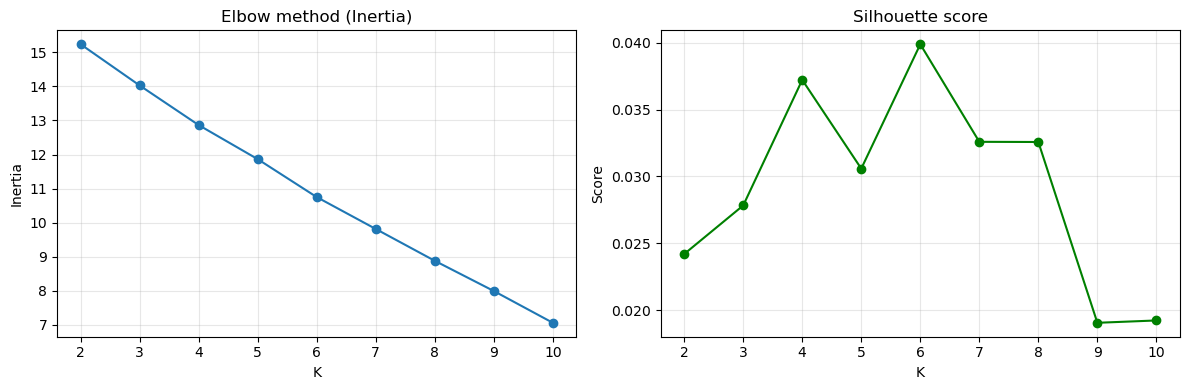

Recommendation: choose the K with a high silhouette score and an elbow in inertia.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

k_values = list(range(2, 11))
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, init='k-means++', random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

best_k_silhouette = k_values[int(np.argmax(silhouettes))]

print("Inertia by K:", dict(zip(k_values, [round(v, 4) for v in inertias])))
print("Silhouette by K:", dict(zip(k_values, [round(v, 4) for v in silhouettes])))
print(f"Best K by silhouette: {best_k_silhouette}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title("Elbow method (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, silhouettes, marker='o', color='green')
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()